In [41]:
# Cell 1A: imports and paths

import pandas as pd
import numpy as np
from pathlib import Path
from scipy import stats
import matplotlib.pyplot as plt

PROJ_ROOT = Path("~").expanduser() / "Desktop" / "shockley_repo"
DATA = PROJ_ROOT / "data"
FIGURES = PROJ_ROOT / "figures" / "figures_GRWs" / "AR1" / "figures_AR1_GRW_Y"
RESULTS = PROJ_ROOT / "results" / "results_GRWs" / "AR1" / "results_AR1_GRW_Y"

FIGURES.mkdir(parents=True, exist_ok=True)
RESULTS.mkdir(parents=True, exist_ok=True)


MODEL_NAME = 'AR(1)-GRW-Y'
MODEL_TAG = 'ar1_grw_y'


In [42]:
# Cell 1B: analysis settings

EPS = 0.49
N = 50000
Y = 20
SEED = 63

rng = np.random.default_rng(SEED)

stage_spans = [
    (0, 4,  "0.70", "0-4"),
    (5, 7,  "0.78", "5-7"),
    (8, 13, "0.86", "8-13"),
    (14, 20,"0.93", "14-20")]

In [43]:
# Cell 1C: load data

df_original = pd.read_csv(DATA / "adjusted_productivity.csv")

print(df_original.shape)
df_original.head()


(54948, 21)


,contribs,contribs_with_corr,current,dblp,department,facultyName,first_asst_job_rank,first_asst_job_year,has_postdoc,is_female,...,phd_rank,phd_year,place,pubs,pubs_adj,pubs_with_corr,pubs_with_corr_adj,recordDate,year,CareerAge
0,0.342857,0.342857,Associate Professor,=Ccedil=etintemel:Ugur,Computer Science,Ugur Cetintemel,21.92,2001,False,False,...,28.65,2001.0,Brown University,2,3.902057,2,3.902057,6/6/11,1998,-3
1,0.250000,0.250000,Associate Professor,=Ccedil=etintemel:Ugur,Computer Science,Ugur Cetintemel,21.92,2001,False,False,...,28.65,2001.0,Brown University,1,1.875160,1,1.875160,6/6/11,1999,-2
2,1.833333,1.833333,Associate Professor,=Ccedil=etintemel:Ugur,Computer Science,Ugur Cetintemel,21.92,2001,False,False,...,28.65,2001.0,Brown University,4,7.214900,4,7.214900,6/6/11,2000,-1
3,1.583333,1.583333,Associate Professor,=Ccedil=etintemel:Ugur,Computer Science,Ugur Cetintemel,21.92,2001,False,False,...,28.65,2001.0,Brown University,3,5.209137,3,5.209137,6/6/11,2001,0
4,1.444444,1.444444,Associate Professor,=Ccedil=etintemel:Ugur,Computer Science,Ugur Cetintemel,21.92,2001,False,False,...,28.65,2001.0,Brown University,4,6.691238,4,6.691238,6/6/11,2002,1


In [44]:
# Cell 2A: build empirical panel

df_original['dblp_id'] = df_original['dblp'] + df_original['phd_year'].astype(str)
working_df = (df_original.sort_values(["dblp_id", "CareerAge"]).copy())

working_df["log_pubs_adj"] = np.log(working_df["pubs_adj"] + EPS)

working_df["pubs_adj_next"] = working_df.groupby("dblp_id")["pubs_adj"].shift(-1)
working_df["CareerAge_next"] = working_df.groupby("dblp_id")["CareerAge"].shift(-1)
working_df["log_pubs_next"] = working_df.groupby("dblp_id")["log_pubs_adj"].shift(-1)

working_df["log_delta"] = working_df["log_pubs_next"] - working_df["log_pubs_adj"]

is_next_year = working_df["CareerAge_next"].eq(working_df["CareerAge"] + 1)
is_in_window = working_df["CareerAge"].between(0, Y - 1)

working_df_fit = (working_df[is_next_year & is_in_window].dropna(subset=["log_pubs_adj", "log_pubs_next"]).copy())

print("Rows in orig:", len(working_df))
print("Rows w/ ok 1yr trans:", len(working_df_fit))
print()
print(working_df_fit[["log_pubs_adj", "log_pubs_next", "log_delta"]].describe())

Rows in orig: 54948
Rows w/ ok 1yr trans: 34701

       log_pubs_adj  log_pubs_next     log_delta
count  34701.000000   34701.000000  34701.000000
mean       1.442084       1.448262      0.006178
std        1.131298       1.123265      1.057639
min       -0.713350      -0.713350     -5.028100
25%        0.924939       0.924939     -0.509761
50%        1.661082       1.661082     -0.026502
75%        2.251545       2.251545      0.523108
max        4.396630       4.396630      4.138016


In [45]:
# Cell 2B: career years

obs_years = np.arange(0, Y + 1)
transition_years = np.arange(0, Y)

print("Prod obs by career year:")
print(working_df.loc[working_df["CareerAge"].between(0, Y), "CareerAge"].value_counts().sort_index().reindex(obs_years))
print()
print("Trans obs by starting career year:")
print(working_df_fit["CareerAge"].value_counts().sort_index().reindex(transition_years))


Prod obs by career year:
CareerAge
0     2069
1     2149
2     2208
3     2252
4     2283
5     2277
6     2214
7     2156
8     2074
9     1992
10    1903
11    1823
12    1713
13    1609
14    1497
15    1373
16    1275
17    1178
18    1096
19    1028
20     957
Name: count, dtype: int64

Trans obs by starting career year:
CareerAge
0     2067
1     2143
2     2202
3     2247
4     2259
5     2200
6     2142
7     2059
8     1985
9     1895
10    1814
11    1710
12    1599
13    1493
14    1367
15    1271
16    1174
17    1094
18    1023
19     957
Name: count, dtype: int64


In [46]:
# Cell 3: log-prod params by career year

year_logprod_rows = []

for year in obs_years:
    subset = working_df[working_df["CareerAge"] == year]
    vals = subset["log_pubs_adj"].dropna()

    year_logprod_rows.append({
        "year": year,
        "n": len(vals),
        "mean_log_productivity": vals.mean(),
        "var_log_productivity": vals.var(ddof=0),
        "sd_log_productivity": vals.std(ddof=0)})

year_logprod_params = pd.DataFrame(year_logprod_rows)
year_logprod_params


,year,n,mean_log_productivity,var_log_productivity,sd_log_productivity
0,0,2069,1.096164,1.169240,1.081314
1,1,2149,1.143948,1.206474,1.098396
2,2,2208,1.420733,1.146156,1.070587
3,3,2252,1.597963,1.111421,1.054239
4,4,2283,1.649832,1.152084,1.073352
5,5,2277,1.685266,1.157075,1.075674
6,6,2214,1.630428,1.173957,1.083493
7,7,2156,1.587435,1.151704,1.073175
8,8,2074,1.510005,1.208534,1.099334
9,9,1992,1.494018,1.177235,1.085005


In [47]:
# Cell 4: fit global, yearwise log ar1 models

def fit_log_ar1(subset):
    x = subset["log_pubs_adj"].to_numpy()
    y = subset["log_pubs_next"].to_numpy()

    if len(x) < 2:
        return {
            "n": len(x),
            "intercept": np.nan,
            "beta": np.nan,
            "sigma_resid": np.nan,
            "var_resid": np.nan,
            "implied_stationary_mean_log": np.nan,
            "implied_stationary_var_log": np.nan,
            "mean_resid": np.nan,
            "sd_resid": np.nan}

    X = np.column_stack([np.ones(len(x)), x])

    intercept, beta = np.linalg.lstsq(X, y, rcond=None)[0]

    y_hat = intercept + beta * x
    resid = y - y_hat

    sigma = np.sqrt(np.mean(resid**2))
    var = sigma**2

    if abs(beta) < 1:
        implied_mean = intercept / (1 - beta)
        implied_var = var / (1 - beta**2)
    else:
        implied_mean = np.nan
        implied_var = np.nan

    return {
        "n": len(x),
        "intercept": intercept,
        "beta": beta,
        "sigma_resid": sigma,
        "var_resid": var,
        "implied_stationary_mean_log": implied_mean,
        "implied_stationary_var_log": implied_var,
        "mean_resid": resid.mean(),
        "sd_resid": resid.std(ddof=0)}


global_ar1_params = pd.DataFrame([{"model": "global", **fit_log_ar1(working_df_fit)}])

year_ar1_rows = []

for year in transition_years:
    subset = working_df_fit[working_df_fit["CareerAge"] == year].copy()
    year_ar1_rows.append({"year": year, **fit_log_ar1(subset)})

year_ar1_params = pd.DataFrame(year_ar1_rows)

print("Global AR(1)")
display(global_ar1_params)

print("Yearwise AR(1)")
display(year_ar1_params)

print("Problematic abs beta >= 1")
display(year_ar1_params.loc[year_ar1_params["beta"].abs() >= 1])


Global AR(1)


,model,n,intercept,beta,sigma_resid,var_resid,implied_stationary_mean_log,implied_stationary_var_log,mean_resid,sd_resid
0,global,34701,0.646586,0.555915,0.930687,0.866178,1.455995,1.253588,2.522661e-16,0.930687


Yearwise AR(1)


,year,n,intercept,beta,sigma_resid,var_resid,implied_stationary_mean_log,implied_stationary_var_log,mean_resid,sd_resid
0,0,2067,0.742623,0.349219,1.044612,1.091213,1.141126,1.242774,-6.823548e-16,1.044612
1,1,2143,0.966299,0.390730,0.991072,0.982224,1.585995,1.159199,5.404501e-16,0.991072
2,2,2202,0.912463,0.480602,0.927570,0.860387,1.756772,1.118808,3.081600e-16,0.927570
3,3,2247,0.808968,0.526583,0.923766,0.853344,1.708786,1.180755,5.533822e-16,0.923766
4,4,2259,0.808450,0.528990,0.914065,0.835514,1.716418,1.160164,1.116612e-16,0.914065
5,5,2200,0.739552,0.525945,0.924041,0.853851,1.560054,1.180359,3.867613e-16,0.924041
6,6,2142,0.679839,0.553301,0.890070,0.792224,1.521918,1.141767,-1.243947e-16,0.890070
7,7,2059,0.626020,0.552978,0.923991,0.853759,1.400425,1.229820,-5.728514e-16,0.923991
8,8,1985,0.662685,0.547129,0.900615,0.811107,1.463295,1.157649,-1.959809e-16,0.900615
9,9,1895,0.553715,0.592112,0.915138,0.837477,1.357516,1.289609,-4.691644e-16,0.915138


Problematic abs beta >= 1


,year,n,intercept,beta,sigma_resid,var_resid,implied_stationary_mean_log,implied_stationary_var_log,mean_resid,sd_resid


In [48]:
# Cell 5: fit init prod model

q0_empirical = working_df.loc[working_df["CareerAge"] == 0,"pubs_adj"].dropna()

alpha_q0 = q0_empirical.mean()

z0_empirical = np.log(q0_empirical + EPS)
mu0_log, sigma0_log = stats.norm.fit(z0_empirical)

print("Exponential q0 scale alpha:", alpha_q0)
print("Log corrected q0 mu:", mu0_log)
print("Log corrected q0 sigma:", sigma0_log)

Exponential q0 scale alpha: 4.3046789420568725
Log corrected q0 mu: 1.0961637068079475
Log corrected q0 sigma: 1.0813141615549793


In [49]:
# Cell 6: yearwise sim helpers

def make_ar1_year_lookup(year_ar1_params):
    return (year_ar1_params.set_index("year")[["intercept", "beta", "sigma_resid"]].to_dict("index"))


ar1_year_lookup = make_ar1_year_lookup(year_ar1_params)


def simulate_year_log_ar1(ar1_year_lookup, n=N, Y=Y, q0_model="exponential", rng=None):
    if rng is None:
        rng = np.random.default_rng()

    trajectories = []

    if q0_model == "exponential":
        q0 = rng.exponential(scale=alpha_q0, size=n)
        z = np.log(q0 + EPS)

    elif q0_model == "log_corrected":
        z = rng.normal(loc=mu0_log, scale=sigma0_log, size=n)
        q0 = np.maximum(np.exp(z) - EPS, 0)

    else:
        raise ValueError("choose init model")

    trajectories.append(q0)

    for t in range(Y):
        intercept = ar1_year_lookup[t]["intercept"]
        beta = ar1_year_lookup[t]["beta"]
        sigma = ar1_year_lookup[t]["sigma_resid"]

        shock = rng.normal(loc=0, scale=sigma, size=n)

        z = intercept + beta * z + shock

        q_next = np.maximum(np.exp(z) - EPS, 0)

        trajectories.append(q_next)

    return np.array(trajectories)


def trajectories_to_dataframe_ar1(trajs):
    years = np.arange(trajs.shape[0])
    ix = np.arange(trajs.shape[1])

    df_sim = pd.DataFrame({
        "CareerAge": np.repeat(years, len(ix)),
        "ix": np.tile(ix, len(years)),
        "pubs_adj": trajs.reshape(-1)})

    df_sim["pubs_adj_next"] = df_sim.groupby("ix")["pubs_adj"].shift(-1)
    df_sim["q_adj_delta"] = df_sim["pubs_adj_next"] - df_sim["pubs_adj"]

    df_sim["log_pubs_adj"] = np.log(df_sim["pubs_adj"] + EPS)
    df_sim["log_pubs_next"] = np.log(df_sim["pubs_adj_next"] + EPS)
    df_sim["log_delta"] = df_sim["log_pubs_next"] - df_sim["log_pubs_adj"]

    return df_sim.dropna().copy()


In [50]:
# Cell 7: simulate yearwise ar1

trajs_year_ar1 = simulate_year_log_ar1(ar1_year_lookup=ar1_year_lookup,n=N,Y=Y,q0_model="exponential",rng=rng)

trajs = trajs_year_ar1
df_trajs = trajectories_to_dataframe_ar1(trajs)

print("trajectory array shape:", trajs.shape)
print()
print("sim'd log increments:")
print(df_trajs["log_delta"].describe())

print()
print("sim'd zero fractions:")
for t in [0, 5, 10, 15, 20]:
    print(f"Year {t}: {(trajs[t] == 0).mean():.4f}")


trajectory array shape: (21, 50000)

sim'd log increments:
count    1000000.000000
mean           0.003536
std            1.016462
min           -4.763797
25%           -0.679552
50%            0.000000
75%            0.683899
max            4.916062
Name: log_delta, dtype: float64

sim'd zero fractions:
Year 0: 0.0000
Year 5: 0.0135
Year 10: 0.0266
Year 15: 0.0382
Year 20: 0.0443


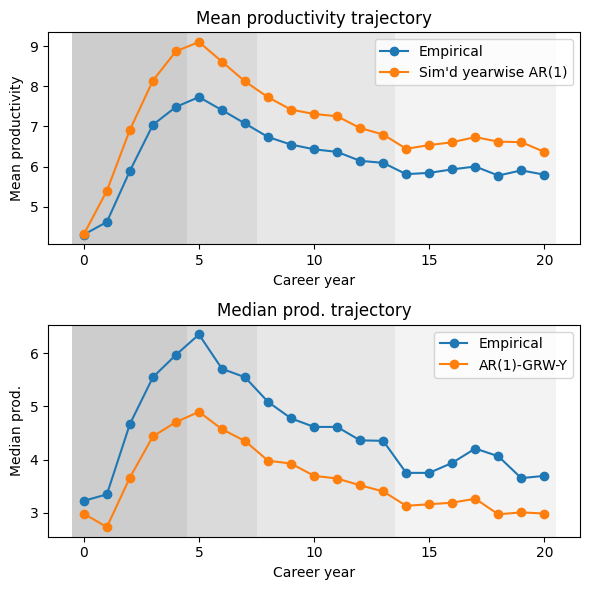

In [51]:
# Cell 8: canonical trajectory check

emp_mean = (working_df[working_df["CareerAge"].between(0, Y)].groupby("CareerAge")["pubs_adj"].mean())

emp_median = (working_df[working_df["CareerAge"].between(0, Y)].groupby("CareerAge")["pubs_adj"].median())

sim_mean = trajs_year_ar1.mean(axis=1)
sim_median = np.median(trajs_year_ar1, axis=1)

years = np.arange(Y + 1)

fig, axes = plt.subplots(2, 1, figsize=(6, 6))
for ax in axes:
    for start, end, shade, label in stage_spans:
        ax.axvspan(start - 0.5,end + 0.5,facecolor=shade,alpha=0.65,zorder=0)

axes[0].plot(emp_mean.index, emp_mean.values, marker="o", label="Empirical", zorder = 3)
axes[0].plot(years, sim_mean, marker="o", label="Sim'd yearwise AR(1)", zorder = 3)
axes[0].set_xlabel("Career year")
axes[0].set_ylabel("Mean productivity")
axes[0].set_title("Mean productivity trajectory")
axes[0].legend()

axes[1].plot(emp_median.index, emp_median.values, marker="o", label="Empirical", zorder = 3)
axes[1].plot(years, sim_median, marker="o", label=MODEL_NAME, zorder = 3)
axes[1].set_xlabel("Career year")
axes[1].set_ylabel("Median prod.")
axes[1].set_title("Median prod. trajectory")
axes[1].legend()

plt.tight_layout()

plt.savefig(FIGURES / f"{MODEL_TAG}_prodSpaceMeanVsMedian.png", dpi=300, bbox_inches="tight")

plt.show()


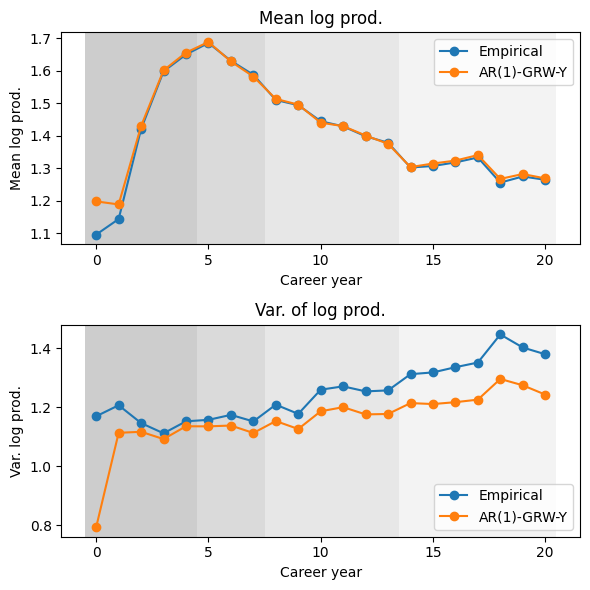

In [52]:
# Cell 9: yearwise log distribution diagnostics

years = np.arange(0, Y + 1)

emp_year_stats = []
for t in years:
    subset = working_df[working_df["CareerAge"] == t]
    q = subset["pubs_adj"].dropna()
    log_q = np.log(q + EPS)

    q_pos = q[q > 0]
    log_q_pos = np.log(q_pos)

    emp_year_stats.append({
        "year": t,
        "n": len(q),
        "frac_zero": (q == 0).mean(),
        "mean_prod": q.mean(),
        "median_prod": q.median(),
        "mean_log_prod": log_q.mean(),
        "var_log_prod": log_q.var(ddof=0),
        "mean_log_prod_pos": log_q_pos.mean(),
        "var_log_prod_pos": log_q_pos.var(ddof=0),
        "q25_prod": q.quantile(0.25),
        "q50_prod": q.quantile(0.50),
        "q75_prod": q.quantile(0.75),
        "q90_prod": q.quantile(0.90),
        "q95_prod": q.quantile(0.95)})

emp_year_stats = pd.DataFrame(emp_year_stats)

sim_year_stats = []
for t in years:
    q = pd.Series(trajs_year_ar1[t])
    log_q = np.log(q + EPS)

    sim_year_stats.append({
        "year": t,
        "n": len(q),
        "frac_zero": (q == 0).mean(),
        "mean_prod": q.mean(),
        "median_prod": q.median(),
        "mean_log_prod": log_q.mean(),
        "var_log_prod": log_q.var(ddof=0),
        "q25_prod": q.quantile(0.25),
        "q50_prod": q.quantile(0.50),
        "q75_prod": q.quantile(0.75),
        "q90_prod": q.quantile(0.90),
        "q95_prod": q.quantile(0.95)})

sim_year_stats = pd.DataFrame(sim_year_stats)

fig, axes = plt.subplots(2, 1, figsize=(6, 6))
for ax in axes:
    for start, end, shade, label in stage_spans:
        ax.axvspan(start - 0.5,end + 0.5,facecolor=shade,alpha=0.65,zorder=0)
axes[0].plot(emp_year_stats["year"], emp_year_stats["mean_log_prod"], marker="o", label="Empirical", zorder = 3)
axes[0].plot(sim_year_stats["year"], sim_year_stats["mean_log_prod"], marker="o", label=MODEL_NAME, zorder = 3)
axes[0].set_title("Mean log prod.")
axes[0].set_xlabel("Career year")
axes[0].set_ylabel("Mean log prod.")
axes[0].legend()

axes[1].plot(emp_year_stats["year"], emp_year_stats["var_log_prod"], marker="o", label="Empirical", zorder = 3)
axes[1].plot(sim_year_stats["year"], sim_year_stats["var_log_prod"], marker="o", label=MODEL_NAME, zorder = 3)
axes[1].set_title("Var. of log prod.")
axes[1].set_xlabel("Career year")
axes[1].set_ylabel("Var. log prod.")
axes[1].legend()

plt.tight_layout()

plt.savefig(FIGURES / f"{MODEL_TAG}_logCompare.png", dpi=300, bbox_inches="tight")
plt.show()


In [53]:
# Cell 10A: yearwise log-delta distrib dx func

def binned_mode(x, bins="auto"):
    x = pd.Series(x).dropna().to_numpy()

    if len(x) == 0:
        return np.nan

    if np.nanmin(x) == np.nanmax(x):
        return float(x[0])

    counts, edges = np.histogram(x, bins=bins)
    k = np.argmax(counts)

    return (edges[k] + edges[k + 1]) / 2


def make_log_delta_stats(df, year_col="CareerAge", delta_col="log_delta", Y=20):

    years = np.arange(0, Y)

    rows = []
    for t in years:
        subset = df[df[year_col] == t]
        dz = subset[delta_col].dropna()

        rows.append({
            "year": t,
            "n": len(dz),
            "mean_log_delta": dz.mean(),
            "median_log_delta": dz.median(),
            "mode_log_delta": binned_mode(dz),
            "var_log_delta": dz.var(ddof=0),
            "q25_log_delta": dz.quantile(0.25),
            "q50_log_delta": dz.quantile(0.50),
            "q75_log_delta": dz.quantile(0.75),
            "q90_log_delta": dz.quantile(0.90),
            "q95_log_delta": dz.quantile(0.95)})

    return pd.DataFrame(rows)

In [54]:
# Cell 10B: yearwise log delta stats get

emp_delta_stats = make_log_delta_stats(working_df_fit,year_col="CareerAge",delta_col="log_delta",Y=Y)

df_sim = trajectories_to_dataframe_ar1(trajs)

sim_delta_stats = make_log_delta_stats(df_sim,year_col="CareerAge",delta_col="log_delta",Y=Y)

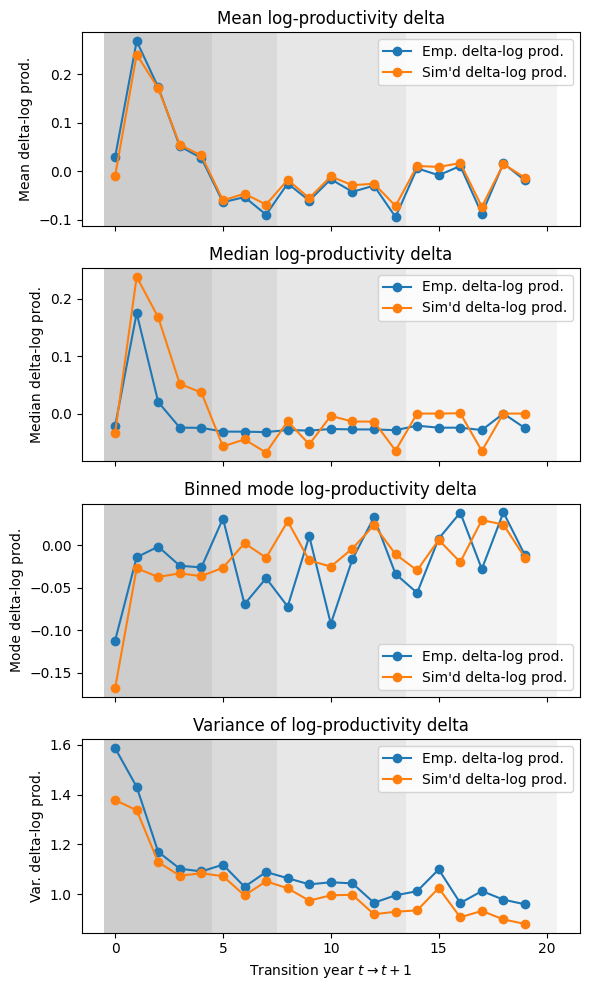

In [55]:
# Cell 11: plot yearwise log-delta moments

fig, axes = plt.subplots(4, 1, figsize=(6, 10), sharex=True)

for ax in axes:
    for start, end, shade, label in stage_spans:
        ax.axvspan(start - 0.5,end + 0.5,facecolor=shade,alpha=0.65,zorder=0)


axes[0].plot(emp_delta_stats["year"],emp_delta_stats["mean_log_delta"],marker="o", label="Emp. delta-log prod.", zorder=3)
axes[0].plot(sim_delta_stats["year"],sim_delta_stats["mean_log_delta"],marker="o",label="Sim'd delta-log prod.", zorder=3)
axes[0].set_title("Mean log-productivity delta")
axes[0].set_ylabel("Mean delta-log prod.")
axes[0].legend()

axes[1].plot(emp_delta_stats["year"],emp_delta_stats["median_log_delta"],marker="o",label="Emp. delta-log prod.",zorder=3)
axes[1].plot(sim_delta_stats["year"],sim_delta_stats["median_log_delta"],marker="o",label="Sim'd delta-log prod.",zorder=3)
axes[1].set_title("Median log-productivity delta")
axes[1].set_ylabel("Median delta-log prod.")
axes[1].legend()

axes[2].plot(emp_delta_stats["year"],emp_delta_stats["mode_log_delta"],marker="o",label="Emp. delta-log prod.",zorder=3)
axes[2].plot(sim_delta_stats["year"],sim_delta_stats["mode_log_delta"],marker="o",label="Sim'd delta-log prod.",zorder=3)
axes[2].set_title("Binned mode log-productivity delta")
axes[2].set_ylabel("Mode delta-log prod.")
axes[2].legend()

axes[3].plot(emp_delta_stats["year"],emp_delta_stats["var_log_delta"],marker="o",label="Emp. delta-log prod.", zorder=3)
axes[3].plot(sim_delta_stats["year"],sim_delta_stats["var_log_delta"],marker="o",label="Sim'd delta-log prod.",zorder=3)
axes[3].set_title("Variance of log-productivity delta")
axes[3].set_xlabel("Transition year $t \\to t+1$")
axes[3].set_ylabel("Var. delta-log prod.")
axes[3].legend()

plt.tight_layout()

plt.savefig(FIGURES / f"{MODEL_TAG}_logDeltaMoments.png",dpi=300,bbox_inches="tight")
plt.show()

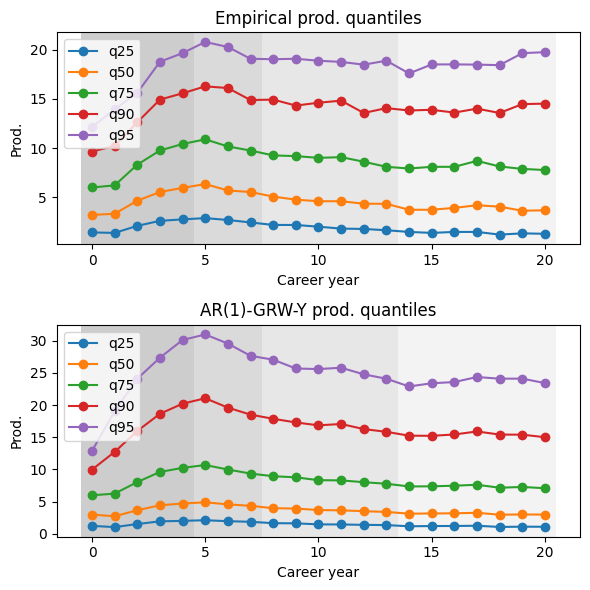

In [56]:
# Cell 12: yearwise productivity quantile diagnostics

qcols = ["q25_prod", "q50_prod", "q75_prod", "q90_prod", "q95_prod"]

fig, axes = plt.subplots(2, 1, figsize=(6, 6))
for ax in axes:
    for start, end, shade, label in stage_spans:
        ax.axvspan(start - 0.5,end + 0.5,facecolor=shade,alpha=0.65,zorder=0)

for qcol in qcols:
    axes[0].plot(emp_year_stats["year"],emp_year_stats[qcol],marker="o",label=qcol.replace("_prod", ""), zorder = 3)

axes[0].set_title("Empirical prod. quantiles")
axes[0].set_xlabel("Career year")
axes[0].set_ylabel("Prod.")
axes[0].legend()

for qcol in qcols:
    axes[1].plot(sim_year_stats["year"],sim_year_stats[qcol],marker="o",label=qcol.replace("_prod", ""), zorder = 3)

axes[1].set_title(f"{MODEL_NAME} prod. quantiles")
axes[1].set_xlabel("Career year")
axes[1].set_ylabel("Prod.")
axes[1].legend()

plt.tight_layout()

plt.savefig(FIGURES / f"{MODEL_TAG}_quantiles.png", dpi=300, bbox_inches="tight")
plt.show()

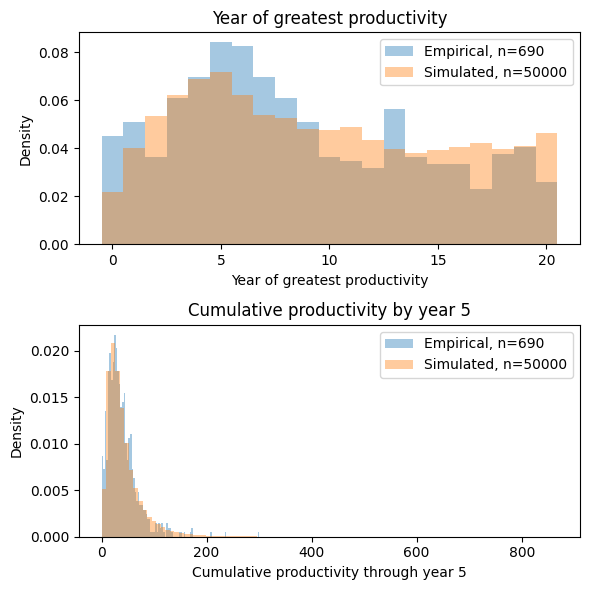

Full empirical trajectories: 690
Simulated trajectories: 50000
KS year of greatest productivity: KstestResult(statistic=np.float64(0.07610492753623188), pvalue=np.float64(0.0007073917074060165), statistic_location=np.int64(9), statistic_sign=np.int8(1))
KS cumulative productivity by year 5: KstestResult(statistic=np.float64(0.04318579710144927), pvalue=np.float64(0.15312945975731196), statistic_location=np.float64(8.778110699481458), statistic_sign=np.int8(1))


In [57]:
# Cell 13: dx, norm'd

emp_panel = (working_df[working_df["CareerAge"].between(0, Y)].pivot_table(index="dblp_id", columns="CareerAge", values="pubs_adj"))

emp_panel_full = emp_panel.dropna()

emp_year_max = emp_panel_full.idxmax(axis=1)
emp_cum_y5 = emp_panel_full.loc[:, 0:5].sum(axis=1)

sim_year_max = np.argmax(trajs_year_ar1, axis=0)
sim_cum_y5 = trajs_year_ar1[0:6, :].sum(axis=0)

ks_year_max = stats.ks_2samp(emp_year_max, sim_year_max)
ks_cum_y5 = stats.ks_2samp(emp_cum_y5, sim_cum_y5)

fig, axes = plt.subplots(2, 1, figsize=(6, 6))

axes[0].hist(emp_year_max,bins=np.arange(-0.5, Y + 1.5, 1),alpha=0.4,density=True,label=f"Empirical, n={len(emp_year_max)}")

axes[0].hist(sim_year_max,bins=np.arange(-0.5, Y + 1.5, 1),alpha=0.4,density=True,label=f"Simulated, n={len(sim_year_max)}")

axes[0].set_xlabel("Year of greatest productivity")
axes[0].set_ylabel("Density")
axes[0].set_title("Year of greatest productivity")
axes[0].legend()

axes[1].hist(emp_cum_y5,bins=100,alpha=0.4,density=True,label=f"Empirical, n={len(emp_cum_y5)}")

axes[1].hist(sim_cum_y5,bins=100,alpha=0.4,density=True, label=f"Simulated, n={len(sim_cum_y5)}")

axes[1].set_xlabel("Cumulative productivity through year 5")
axes[1].set_ylabel("Density")
axes[1].set_title("Cumulative productivity by year 5")
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES / f'{MODEL_TAG}_compareDistribs')
plt.show()

print("Full empirical trajectories:", len(emp_panel_full))
print("Simulated trajectories:", trajs_year_ar1.shape[1])
print("KS year of greatest productivity:", ks_year_max)
print("KS cumulative productivity by year 5:", ks_cum_y5)

In [58]:
# Cell 14: numerical summary

summary = {
    "empirical_mean_y0": emp_mean.loc[0],
    "empirical_mean_y5": emp_mean.loc[5],
    "empirical_mean_y10": emp_mean.loc[10],
    "empirical_mean_y20": emp_mean.loc[20],
    "simulated_mean_y0": sim_mean[0],
    "simulated_mean_y5": sim_mean[5],
    "simulated_mean_y10": sim_mean[10],
    "simulated_mean_y20": sim_mean[20],
    "empirical_median_y0": emp_median.loc[0],
    "empirical_median_y5": emp_median.loc[5],
    "empirical_median_y10": emp_median.loc[10],
    "empirical_median_y20": emp_median.loc[20],
    "simulated_median_y0": sim_median[0],
    "simulated_median_y5": sim_median[5],
    "simulated_median_y10": sim_median[10],
    "simulated_median_y20": sim_median[20],
    "simulated_y20_q95": np.quantile(trajs_year_ar1[20], 0.95),
    "simulated_y20_q99": np.quantile(trajs_year_ar1[20], 0.99),
    "simulated_y20_max": np.max(trajs_year_ar1[20]),
    "ks_year_max_stat": ks_year_max.statistic,
    "ks_year_max_p": ks_year_max.pvalue,
    "ks_cum_y5_stat": ks_cum_y5.statistic,
    "ks_cum_y5_p": ks_cum_y5.pvalue}

summary_df = pd.DataFrame([summary])

print("Yearwise log-prod params")
display(year_logprod_params)

print("Yearwise AR(1) params")
display(year_ar1_params)

print("Summary")
display(summary_df)


Yearwise log-prod params


,year,n,mean_log_productivity,var_log_productivity,sd_log_productivity
0,0,2069,1.096164,1.169240,1.081314
1,1,2149,1.143948,1.206474,1.098396
2,2,2208,1.420733,1.146156,1.070587
3,3,2252,1.597963,1.111421,1.054239
4,4,2283,1.649832,1.152084,1.073352
5,5,2277,1.685266,1.157075,1.075674
6,6,2214,1.630428,1.173957,1.083493
7,7,2156,1.587435,1.151704,1.073175
8,8,2074,1.510005,1.208534,1.099334
9,9,1992,1.494018,1.177235,1.085005


Yearwise AR(1) params


,year,n,intercept,beta,sigma_resid,var_resid,implied_stationary_mean_log,implied_stationary_var_log,mean_resid,sd_resid
0,0,2067,0.742623,0.349219,1.044612,1.091213,1.141126,1.242774,-6.823548e-16,1.044612
1,1,2143,0.966299,0.390730,0.991072,0.982224,1.585995,1.159199,5.404501e-16,0.991072
2,2,2202,0.912463,0.480602,0.927570,0.860387,1.756772,1.118808,3.081600e-16,0.927570
3,3,2247,0.808968,0.526583,0.923766,0.853344,1.708786,1.180755,5.533822e-16,0.923766
4,4,2259,0.808450,0.528990,0.914065,0.835514,1.716418,1.160164,1.116612e-16,0.914065
5,5,2200,0.739552,0.525945,0.924041,0.853851,1.560054,1.180359,3.867613e-16,0.924041
6,6,2142,0.679839,0.553301,0.890070,0.792224,1.521918,1.141767,-1.243947e-16,0.890070
7,7,2059,0.626020,0.552978,0.923991,0.853759,1.400425,1.229820,-5.728514e-16,0.923991
8,8,1985,0.662685,0.547129,0.900615,0.811107,1.463295,1.157649,-1.959809e-16,0.900615
9,9,1895,0.553715,0.592112,0.915138,0.837477,1.357516,1.289609,-4.691644e-16,0.915138


Summary


,empirical_mean_y0,empirical_mean_y5,empirical_mean_y10,empirical_mean_y20,simulated_mean_y0,simulated_mean_y5,simulated_mean_y10,simulated_mean_y20,empirical_median_y0,empirical_median_y5,...,simulated_median_y5,simulated_median_y10,simulated_median_y20,simulated_y20_q95,simulated_y20_q99,simulated_y20_max,ks_year_max_stat,ks_year_max_p,ks_cum_y5_stat,ks_cum_y5_p
0,4.304679,7.729319,6.428626,5.797863,4.312892,9.10222,7.308657,6.365236,3.225469,6.352937,...,4.89832,3.694178,2.985274,23.414361,52.400355,562.225109,0.076105,0.000707,0.043186,0.153129


In [59]:
# Cell 15: save outputs

year_logprod_params.to_csv(RESULTS / f"{MODEL_TAG}_stageLogProdParams.csv", index=False)
year_ar1_params.to_csv(RESULTS / f"{MODEL_TAG}_stageLogParams.csv", index=False)
global_ar1_params.to_csv(RESULTS / f"{MODEL_TAG}_globalParams.csv", index=False)
emp_year_stats.to_csv(RESULTS / f"{MODEL_TAG}_empYearStats.csv", index=False)
sim_year_stats.to_csv(RESULTS / f"{MODEL_TAG}_simYearStats.csv", index=False)
summary_df.to_csv(RESULTS / f"{MODEL_TAG}_Summary.csv", index=False)
emp_delta_stats.to_csv(RESULTS / f"{MODEL_TAG}_empLogDeltaStats.csv",index=False)
sim_delta_stats.to_csv(RESULTS / f"{MODEL_TAG}_simLogDeltaStats.csv",index=False)

with open(RESULTS / f"{MODEL_TAG}_report.txt", "w") as f:
    f.write("AR(1)-GRW-Y report\n")
    f.write("\n\n")

    f.write("Model\n")
    f.write("\n")
    f.write("z_{t+1} = intercept_t + beta_t z_t + error_{t}\n")
    f.write("where z_t = log(pubs_adj_t + EPS).\n\n")

    f.write(f"EPS = {EPS}\n")
    f.write(f"N = {N}\n")
    f.write(f"Y = {Y}\n\n")

    f.write("Year log-productivity parameters\n")
    f.write("\n")
    f.write(year_logprod_params.to_string(index=False))

    f.write("\n\nYear AR(1) parameters\n")
    f.write("\n")
    f.write(year_ar1_params.to_string(index=False))

    f.write("\n\nGlobal AR(1) parameters\n")
    f.write("\n")
    f.write(global_ar1_params.to_string(index=False))

    f.write("\n\nsummary\n")
    f.write("-------\n")
    f.write(summary_df.to_string(index=False))

In [60]:
OUT = PROJ_ROOT / "data" / 'trajectory_correlation_data'

TRJ = trajs     

TRJ = np.asarray(TRJ)
if TRJ.shape[0] != 21 and TRJ.shape[1] == 21:
    TRJ = TRJ.T

assert TRJ.shape[0] == 21, f"expected 21 years, got {TRJ.shape}"

save_path = OUT / f"{MODEL_TAG}_trajs.npy"
np.save(save_path, TRJ)

print(f"Saved trajectories to: {save_path}")


Saved trajectories to: /Users/samlunemagid/Desktop/shockley_repo/data/trajectory_correlation_data/ar1_grw_y_trajs.npy
